# FOV stage/organ summary

This notebook answers:
1. How many FOVs per **Pathological stage** and per **GI stage**.
2. How many FOVs are **Duodenum** vs **Colon**.
3. What image resolution(s) exist.
4. What the **S_ control FOVs** are and what is spatially special about them.
5. One example FOV for each **stage x organ** combination.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator, FuncFormatter
from pathlib import Path

In [2]:
base = Path("../data/MIBIGutCsv")
fov_path = base / "fovs_metadata.csv"
biopsy_path = base / "biopsy_metadata.csv"
cell_path = base / "cell_table.csv"

fov_df = pd.read_csv(fov_path)
biopsy_df = pd.read_csv(biopsy_path)
cell_df = pd.read_csv(cell_path)

print("fov_df shape:", fov_df.shape)
print("biopsy_df shape:", biopsy_df.shape)
print("cell_df shape:", cell_df.shape)

fov_df shape: (288, 4)
biopsy_df shape: (59, 40)
cell_df shape: (713372, 55)


In [3]:
# Keep only columns needed for this analysis.
biopsy_small = biopsy_df[["Biopsy_ID", "Pathological stage", "GI stage", "Localization"]].copy()

# In this project, fovs_metadata.Patient maps to biopsy_metadata.Biopsy_ID.
merged = fov_df.merge(
    biopsy_small,
    left_on="Patient",
    right_on="Biopsy_ID",
    how="left"
)

print("merged shape:", merged.shape)

merged shape: (288, 8)


In [4]:
def infer_organ_from_cohort(cohort_value):
    text = str(cohort_value).lower()
    if "duodenum" in text:
        return "Duodenum"
    if "colon" in text:
        return "Colon"
    return None


def infer_organ_from_localization(localization_value):
    text = str(localization_value).strip().lower()
    if text == "duodenum":
        return "Duodenum"
    if text == "colon":
        return "Colon"
    return None


def stage_label(value):
    if pd.isna(value):
        return "Control"
    return str(int(value))


cohort_organ = merged["Cohort"].apply(infer_organ_from_cohort)
loc_organ = merged["Localization"].apply(infer_organ_from_localization)
merged["Organ"] = cohort_organ.fillna(loc_organ).fillna("Unknown")

unknown_count = (merged["Organ"] == "Unknown").sum()
print("Unknown organ FOVs:", unknown_count)
if unknown_count > 0:
    print("Example unknown rows:")
    display(merged.loc[merged["Organ"] == "Unknown", ["FOV", "Patient", "Cohort", "Localization"]].head(20))
    raise ValueError("Organ inference failed for some rows. Check Cohort/Localization values above.")
merged["Pathological stage label"] = merged["Pathological stage"].apply(stage_label)
merged["GI stage label"] = merged["GI stage"].apply(stage_label)

merged[["FOV", "Patient", "Cohort", "Localization", "Organ", "Pathological stage label", "GI stage label", "Size [um]"]].head()

Unknown organ FOVs: 0


,FOV,Patient,Cohort,Localization,Organ,Pathological stage label,GI stage label,Size [um]
0,Control_01_FOV_1,Control_01,Duodenum_Cohort_Control_1,NaN,Duodenum,Control,Control,400
1,Control_01_FOV_2,Control_01,Duodenum_Cohort_Control_1,NaN,Duodenum,Control,Control,400
2,Control_01_FOV_3,Control_01,Duodenum_Cohort_Control_1,NaN,Duodenum,Control,Control,400
3,Control_01_FOV_4,Control_01,Duodenum_Cohort_Control_1,NaN,Duodenum,Control,Control,400
4,Control_02_FOV_1,Control_02,Duodenum_Cohort_Control_1,NaN,Duodenum,Control,Control,400


In [5]:
print("FOV count by Pathological stage")
display(
    merged["Pathological stage label"]
    .value_counts(dropna=False)
    .rename_axis("Pathological stage")
    .reset_index(name="FOV count")
)

print("FOV count by GI stage")
display(
    merged["GI stage label"]
    .value_counts(dropna=False)
    .rename_axis("GI stage")
    .reset_index(name="FOV count")
)

FOV count by Pathological stage


,Pathological stage,FOV count
0,0,84
1,Control,77
2,1,59
3,2,43
4,3,25


FOV count by GI stage


,GI stage,FOV count
0,1,79
1,Control,77
2,2,69
3,0,37
4,3,26


In [6]:
print("FOV count by Organ (Duodenum / Colon)")
display(
    merged["Organ"]
    .value_counts(dropna=False)
    .rename_axis("Organ")
    .reset_index(name="FOV count")
)

FOV count by Organ (Duodenum / Colon)


,Organ,FOV count
0,Duodenum,191
1,Colon,97


In [7]:
print("FOV count by Pathological stage x Organ")
path_stage_organ = pd.crosstab(merged["Pathological stage label"], merged["Organ"])
display(path_stage_organ)

print("FOV count by GI stage x Organ")
gi_stage_organ = pd.crosstab(merged["GI stage label"], merged["Organ"])
display(gi_stage_organ)

FOV count by Pathological stage x Organ


Organ,Colon,Duodenum
Pathological stage label,,
0,14,70
1,26,33
2,24,19
3,8,17
Control,25,52


FOV count by GI stage x Organ


Organ,Colon,Duodenum
GI stage label,,
0,4,33
1,14,65
2,40,29
3,14,12
Control,25,52


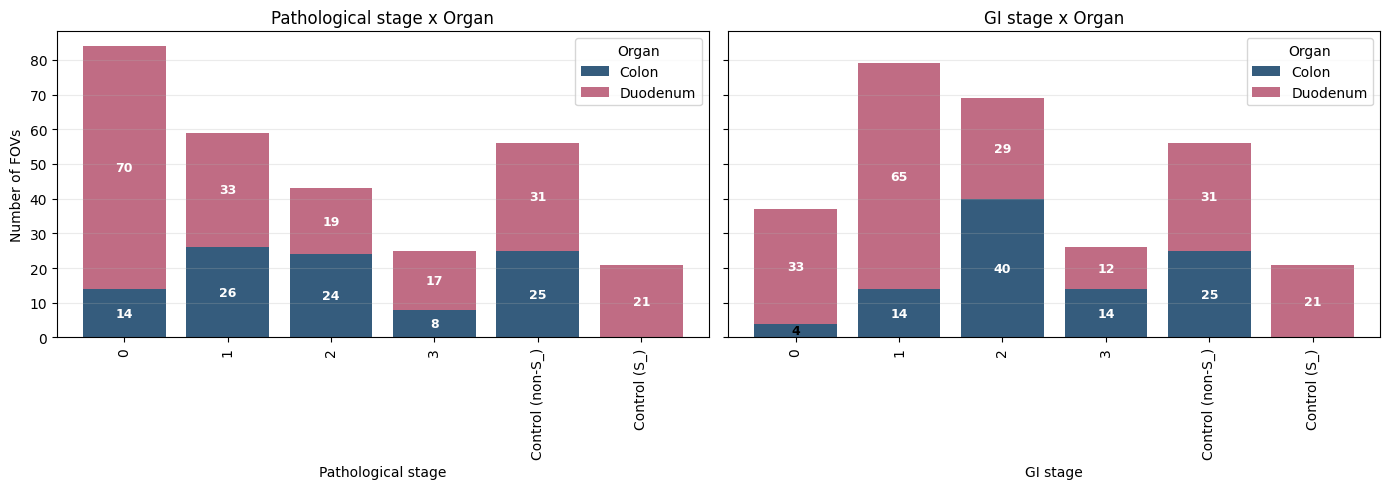

In [8]:
# Same summary tables shown in chat, with controls split to S_ / non-S_.
stage_order = ["0", "1", "2", "3", "Control (non-S_)", "Control (S_)"]
organ_order = ["Colon", "Duodenum"]

is_s_fov = merged["FOV"].astype(str).str.startswith("S_")
is_control_path = merged["Pathological stage label"].astype(str).isin(["Control", "Control/Unknown"])
is_control_gi = merged["GI stage label"].astype(str).isin(["Control", "Control/Unknown"])

path_stage_for_bar = merged["Pathological stage label"].astype(str).copy()
path_stage_for_bar.loc[is_control_path & is_s_fov] = "Control (S_)"
path_stage_for_bar.loc[is_control_path & ~is_s_fov] = "Control (non-S_)"

gi_stage_for_bar = merged["GI stage label"].astype(str).copy()
gi_stage_for_bar.loc[is_control_gi & is_s_fov] = "Control (S_)"
gi_stage_for_bar.loc[is_control_gi & ~is_s_fov] = "Control (non-S_)"

path_stage_organ_table = pd.crosstab(path_stage_for_bar, merged["Organ"]).reindex(
    index=stage_order,
    columns=organ_order,
    fill_value=0
)
gi_stage_organ_table = pd.crosstab(gi_stage_for_bar, merged["Organ"]).reindex(
    index=stage_order,
    columns=organ_order,
    fill_value=0
)

path_counts = path_stage_organ_table.copy()
gi_counts = gi_stage_organ_table.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
bar_colors = ["#355C7D", "#C06C84"]

path_counts.plot(kind="bar", stacked=True, ax=axes[0], color=bar_colors, width=0.8)
axes[0].set_title("Pathological stage x Organ")
axes[0].set_xlabel("Pathological stage")
axes[0].set_ylabel("Number of FOVs")
axes[0].legend(title="Organ", loc="upper right")

gi_counts.plot(kind="bar", stacked=True, ax=axes[1], color=bar_colors, width=0.8)
axes[1].set_title("GI stage x Organ")
axes[1].set_xlabel("GI stage")
axes[1].set_ylabel("")
axes[1].legend(title="Organ", loc="upper right")

def add_absolute_labels(ax, counts_df):
    cumulative = [0] * len(counts_df)
    for organ in counts_df.columns:
        vals = counts_df[organ].tolist()
        for i, v in enumerate(vals):
            if v > 0:
                y = cumulative[i] + v / 2
                txt_color = "white" if v >= 6 else "black"
                ax.text(i, y, str(int(v)), ha="center", va="center", fontsize=9, fontweight="bold", color=txt_color)
        cumulative = [cumulative[i] + vals[i] for i in range(len(vals))]

add_absolute_labels(axes[0], path_counts)
add_absolute_labels(axes[1], gi_counts)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

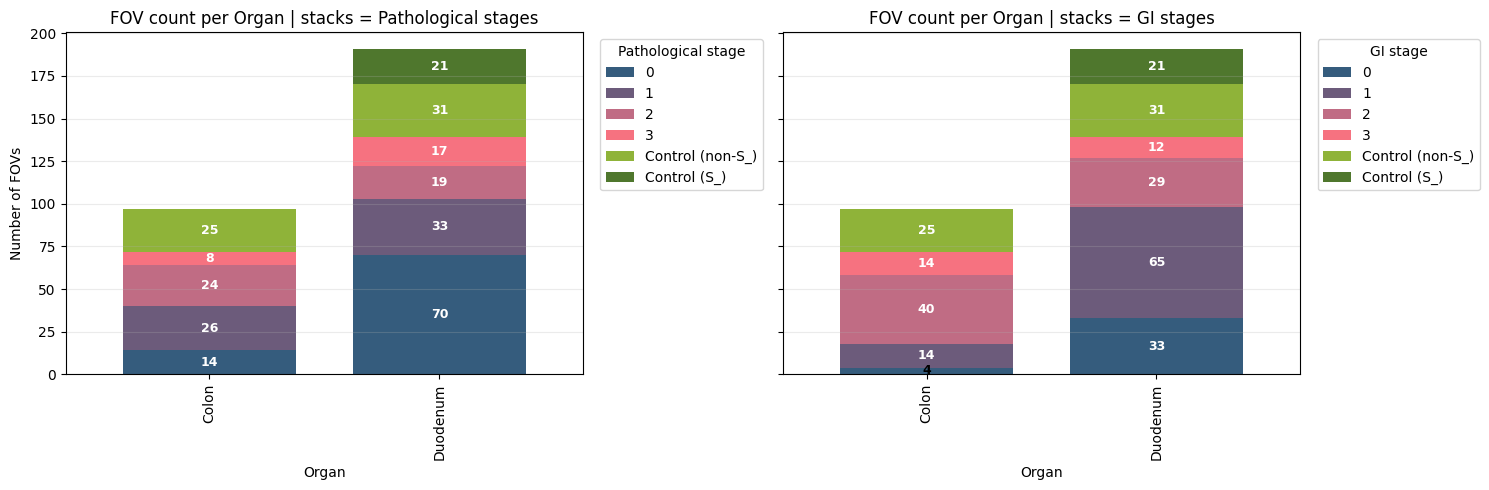

In [9]:
# Pivoted view: bars are organs, stacks are stages (counts).
# Two charts: Pathological stages and GI stages.
stage_order = ["0", "1", "2", "3", "Control (non-S_)", "Control (S_)"]
organ_order = ["Colon", "Duodenum"]

is_s_fov = merged["FOV"].astype(str).str.startswith("S_")
is_control_path = merged["Pathological stage label"].astype(str).isin(["Control", "Control/Unknown"])
is_control_gi = merged["GI stage label"].astype(str).isin(["Control", "Control/Unknown"])

path_stage_for_bar = merged["Pathological stage label"].astype(str).copy()
path_stage_for_bar.loc[is_control_path & is_s_fov] = "Control (S_)"
path_stage_for_bar.loc[is_control_path & ~is_s_fov] = "Control (non-S_)"

gi_stage_for_bar = merged["GI stage label"].astype(str).copy()
gi_stage_for_bar.loc[is_control_gi & is_s_fov] = "Control (S_)"
gi_stage_for_bar.loc[is_control_gi & ~is_s_fov] = "Control (non-S_)"

path_organ_stage = pd.crosstab(merged["Organ"], path_stage_for_bar).reindex(
    index=organ_order,
    columns=stage_order,
    fill_value=0
)

gi_organ_stage = pd.crosstab(merged["Organ"], gi_stage_for_bar).reindex(
    index=organ_order,
    columns=stage_order,
    fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
stage_colors = ["#355C7D", "#6C5B7B", "#C06C84", "#F67280", "#8FB339", "#4F772D"]

path_organ_stage.plot(kind="bar", stacked=True, ax=axes[0], color=stage_colors, width=0.75)
axes[0].set_title("FOV count per Organ | stacks = Pathological stages")
axes[0].set_xlabel("Organ")
axes[0].set_ylabel("Number of FOVs")
axes[0].legend(title="Pathological stage", bbox_to_anchor=(1.02, 1), loc="upper left")

gi_organ_stage.plot(kind="bar", stacked=True, ax=axes[1], color=stage_colors, width=0.75)
axes[1].set_title("FOV count per Organ | stacks = GI stages")
axes[1].set_xlabel("Organ")
axes[1].set_ylabel("")
axes[1].legend(title="GI stage", bbox_to_anchor=(1.02, 1), loc="upper left")

def add_absolute_labels(ax, counts_df):
    cumulative = [0] * len(counts_df)
    for col in counts_df.columns:
        vals = counts_df[col].tolist()
        for i, v in enumerate(vals):
            if v > 0:
                y = cumulative[i] + v / 2
                txt_color = "white" if v >= 6 else "black"
                ax.text(i, y, str(int(v)), ha="center", va="center", fontsize=9, fontweight="bold", color=txt_color)
        cumulative = [cumulative[i] + vals[i] for i in range(len(vals))]

add_absolute_labels(axes[0], path_organ_stage)
add_absolute_labels(axes[1], gi_organ_stage)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [10]:
# Resolution summary from Size [um] and known pixel standards used in the pipeline.
resolution_map = {
    400: "1024 x 1024 px (0.390625 um/px)",
    800: "2048 x 2048 px (0.390625 um/px)"
}

res_df = (
    merged[["Size [um]"]]
    .value_counts()
    .reset_index(name="FOV count")
    .rename(columns={"Size [um]": "Size_um"})
)
res_df["Pixel resolution"] = res_df["Size_um"].map(resolution_map).fillna("Unknown")
display(res_df)

,Size_um,FOV count,Pixel resolution
0,400,259,1024 x 1024 px (0.390625 um/px)
1,800,29,2048 x 2048 px (0.390625 um/px)


In [11]:
# S_ controls: what is spatially special about them?
# We compare them against regular Control_ FOVs.

is_control = (
    merged["FOV"].str.contains("control", case=False, na=False)
    | merged["Cohort"].str.contains("control", case=False, na=False)
)

control_df = merged[is_control].copy()
s_control = control_df[control_df["FOV"].str.startswith("S_", na=False)].copy()
regular_control = control_df[control_df["FOV"].str.startswith("Control_", na=False)].copy()

print("S_ control FOV count:", len(s_control))
print("Regular Control_ FOV count:", len(regular_control))

print("S_ control cohort values:")
display(s_control["Cohort"].value_counts(dropna=False).reset_index(name="FOV count").rename(columns={"index": "Cohort"}))

print("S_ control size/resolution distribution:")
display(s_control["Size [um]"].value_counts(dropna=False).reset_index(name="FOV count").rename(columns={"index": "Size [um]"}))

print("Regular Control_ size/resolution distribution:")
display(regular_control["Size [um]"].value_counts(dropna=False).reset_index(name="FOV count").rename(columns={"index": "Size [um]"}))

print("S_ control rows (preview)")
display(s_control[["FOV", "Patient", "Cohort", "Size [um]"]].sort_values(["Patient", "FOV"]).head(30))

S_ control FOV count: 21
Regular Control_ FOV count: 56
S_ control cohort values:


,Cohort,FOV count
0,Duodenum_Cohort_Control_2,21


S_ control size/resolution distribution:


,Size [um],FOV count
0,800,21


Regular Control_ size/resolution distribution:


,Size [um],FOV count
0,400,48
1,800,8


S_ control rows (preview)


,FOV,Patient,Cohort,Size [um]
242,S_01_FOV_1,S_01,Duodenum_Cohort_Control_2,800
243,S_01_FOV_2,S_01,Duodenum_Cohort_Control_2,800
244,S_01_FOV_3,S_01,Duodenum_Cohort_Control_2,800
245,S_01_FOV_4,S_01,Duodenum_Cohort_Control_2,800
246,S_02_FOV_1,S_02,Duodenum_Cohort_Control_2,800
247,S_02_FOV_2,S_02,Duodenum_Cohort_Control_2,800
248,S_02_FOV_3,S_02,Duodenum_Cohort_Control_2,800
249,S_02_FOV_4,S_02,Duodenum_Cohort_Control_2,800
250,S_02_FOV_5,S_02,Duodenum_Cohort_Control_2,800
251,S_03_FOV_1,S_03,Duodenum_Cohort_Control_2,800


In [12]:
# One example FOV for each Pathological stage x Organ combination.
path_examples = (
    merged.assign(_prefer_800=(merged["Size [um]"] == 800).astype(int))
    .sort_values(["Pathological stage label", "Organ", "_prefer_800", "FOV"], ascending=[True, True, False, True])
    .groupby(["Pathological stage label", "Organ"], as_index=False)
    .first()
    .drop(columns=["_prefer_800"])
)

display(path_examples[["Pathological stage label", "Organ", "FOV", "Patient", "Cohort", "Size [um]"]])

,Pathological stage label,Organ,FOV,Patient,Cohort,Size [um]
0,0,Colon,GVHD_13_FOV_1,GVHD_13,Cohort_GVHD,400
1,0,Duodenum,GVHD_03_FOV_1_R,GVHD_03,Cohort_GVHD,400
2,1,Colon,GVHD_17_FOV_1,GVHD_17,Cohort_GVHD,400
3,1,Duodenum,GVHD_10_FOV_1,GVHD_10,Cohort_GVHD,400
4,2,Colon,GVHD_01_FOV_1,GVHD_01,Cohort_GVHD,400
5,2,Duodenum,GVHD_02_FOV_1_R,GVHD_02,Cohort_GVHD,400
6,3,Colon,GVHD_25_FOV_1,GVHD_25,Cohort_GVHD,400
7,3,Duodenum,GVHD_06_FOV_1,GVHD_06,Cohort_GVHD,400
8,Control,Colon,Control_Colon_01_FOV_6,Control_Colon_01,Colon_Cohort_Control,800
9,Control,Duodenum,S_01_FOV_1,S_01,Duodenum_Cohort_Control_2,800


In [13]:
# One example FOV for each GI stage x Organ combination.
gi_examples = (
    merged.assign(_prefer_800=(merged["Size [um]"] == 800).astype(int))
    .sort_values(["GI stage label", "Organ", "_prefer_800", "FOV"], ascending=[True, True, False, True])
    .groupby(["GI stage label", "Organ"], as_index=False)
    .first()
    .drop(columns=["_prefer_800"])
)

display(gi_examples[["GI stage label", "Organ", "FOV", "Patient", "Cohort", "Size [um]"]])

,GI stage label,Organ,FOV,Patient,Cohort,Size [um]
0,0,Colon,GVHD_53_FOV_1,GVHD_53,Cohort_GVHD,400
1,0,Duodenum,GVHD_27_FOV_1,GVHD_27,Cohort_GVHD,400
2,1,Colon,GVHD_13_FOV_1,GVHD_13,Cohort_GVHD,400
3,1,Duodenum,GVHD_02_FOV_1_R,GVHD_02,Cohort_GVHD,400
4,2,Colon,GVHD_01_FOV_1,GVHD_01,Cohort_GVHD,400
5,2,Duodenum,GVHD_06_FOV_1,GVHD_06,Cohort_GVHD,400
6,3,Colon,GVHD_22_FOV_1,GVHD_22,Cohort_GVHD,400
7,3,Duodenum,GVHD_09_FOV_1,GVHD_09,Cohort_GVHD,400
8,Control,Colon,Control_Colon_01_FOV_6,Control_Colon_01,Colon_Cohort_Control,800
9,Control,Duodenum,S_01_FOV_1,S_01,Duodenum_Cohort_Control_2,800


In [14]:
# Prepare cell table for full-FOV plotting.
cells_plot = cell_df.rename(columns={"centroid_x": "x", "centroid_y": "y", "cell type": "cell_type"}).copy()

if "x" not in cells_plot.columns or "y" not in cells_plot.columns or "cell_type" not in cells_plot.columns:
    raise ValueError("cell_table.csv is missing required columns for plotting")

fov_size_um_map = dict(zip(fov_df["FOV"], fov_df["Size [um]"]))

all_types = sorted(cells_plot["cell_type"].dropna().astype(str).unique())
# Darker categorical palette.
palette = plt.cm.get_cmap("tab20b", max(len(all_types), 1))
cell_color_map = {ct: palette(i) for i, ct in enumerate(all_types)}

def show_celltype_colormap():
    n = len(all_types)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig_h = max(3, 0.35 * nrows)
    fig, ax = plt.subplots(figsize=(8, fig_h))
    ax.axis("off")
    for i, ct in enumerate(all_types):
        col = i // nrows
        row = i % nrows
        x = 0.05 + col * 0.47
        y = 0.95 - row * (0.9 / max(nrows, 1))
        ax.add_patch(plt.Rectangle((x, y - 0.025), 0.04, 0.035, color=cell_color_map[ct], transform=ax.transAxes))
        ax.text(x + 0.05, y - 0.007, ct, transform=ax.transAxes, fontsize=9, va="center", color="black")
    ax.set_title("Cell type colormap", fontsize=11)
    plt.tight_layout()
    plt.show()

def add_scale_bar_50um(ax, x_max, y_max, size_um):
    # Dataset standard: 400um->1024px and 800um->2048px => same px_per_um (2.56)
    px_per_um = 1024.0 / 400.0 if float(size_um) == 400.0 else 2048.0 / 800.0
    bar_px = 50.0 * px_per_um
    x_end = x_max - 25
    x_start = x_end - bar_px
    y_line = y_max - 25
    ax.plot([x_start, x_end], [y_line, y_line], color="black", linewidth=4, solid_capstyle="butt")
    ax.text((x_start + x_end) / 2, y_line - 12, "50 µm", color="black", ha="center", va="bottom", fontsize=10)

def plot_full_fov_on_ax(ax, fov_id, title, show_legend=False):
    df_fov = cells_plot[cells_plot["fov"] == fov_id].copy()
    if df_fov.empty:
        ax.text(0.5, 0.5, f"No cells for {fov_id}", ha="center", va="center")
        ax.set_axis_off()
        return

    ax.set_facecolor("#f2f2f2")
    size_um = fov_size_um_map.get(fov_id, 400)
    base_s = 20 if float(size_um) == 400.0 else 13

    for ct, g in df_fov.groupby("cell_type"):
        color = cell_color_map.get(ct, (1, 1, 1))
        ax.scatter(g["x"], g["y"], s=base_s * 3.2, c=[color], alpha=0.09, linewidths=0)
        ax.scatter(g["x"], g["y"], s=base_s, c=[color], label=ct, alpha=0.9, linewidths=0)

    x_max = df_fov["x"].max()
    y_max = df_fov["y"].max()
    px_per_um = 1024.0 / 400.0 if float(size_um) == 400.0 else 2048.0 / 800.0
    grid_px = 25.0 * px_per_um
    major_px = 100.0 * px_per_um
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MultipleLocator(major_px))
    ax.yaxis.set_major_locator(MultipleLocator(major_px))
    ax.xaxis.set_minor_locator(MultipleLocator(grid_px))
    ax.yaxis.set_minor_locator(MultipleLocator(grid_px))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(round(v / px_per_um))}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(round(v / px_per_um))}"))
    ax.grid(which="major", color="#cfcfcf", linestyle="-", linewidth=0.8, alpha=1.0)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7, alpha=0.9)
    add_scale_bar_50um(ax, x_max=x_max, y_max=y_max, size_um=size_um)

    ax.set_title(title, color="black", fontsize=10)
    ax.set_xlabel("x (µm)", color="black")
    ax.set_ylabel("y (µm)", color="black")
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.tick_params(axis="both", colors="black", labelsize=7)
    for spine in ax.spines.values():
        spine.set_visible(False)

    if show_legend:
        handles = [
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cell_color_map[ct], markeredgecolor="none", markersize=5, label=ct)
            for ct in all_types
        ]
        ax.legend(handles=handles, title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, title_fontsize=8, frameon=True)

def plot_full_fov_by_id(fov_id, title, show_legend=True):
    fig, ax = plt.subplots(figsize=(7, 7), facecolor="#f2f2f2")
    plot_full_fov_on_ax(ax, fov_id, title, show_legend=show_legend)
    plt.tight_layout()
    plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_21764\1683845049.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab20b", max(len(all_types), 1))


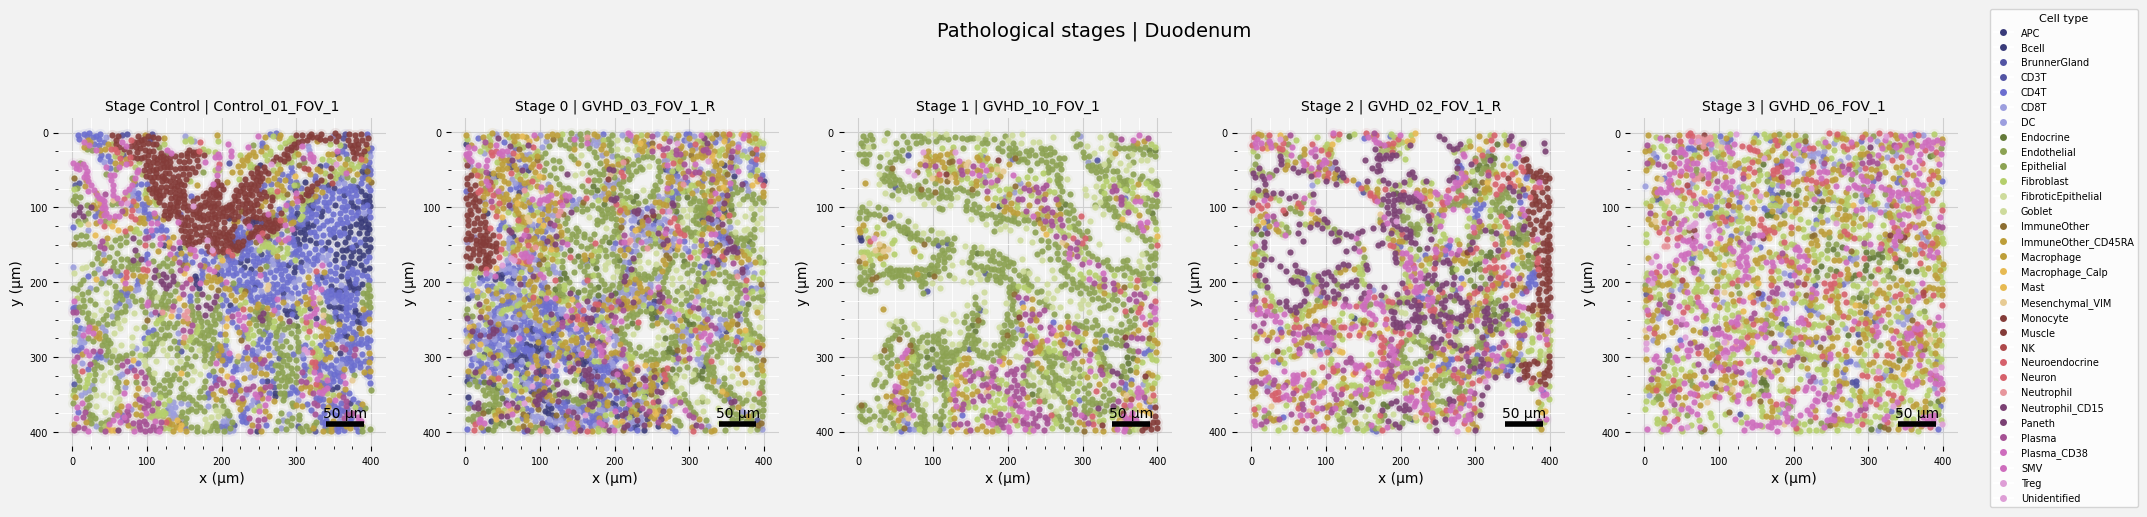

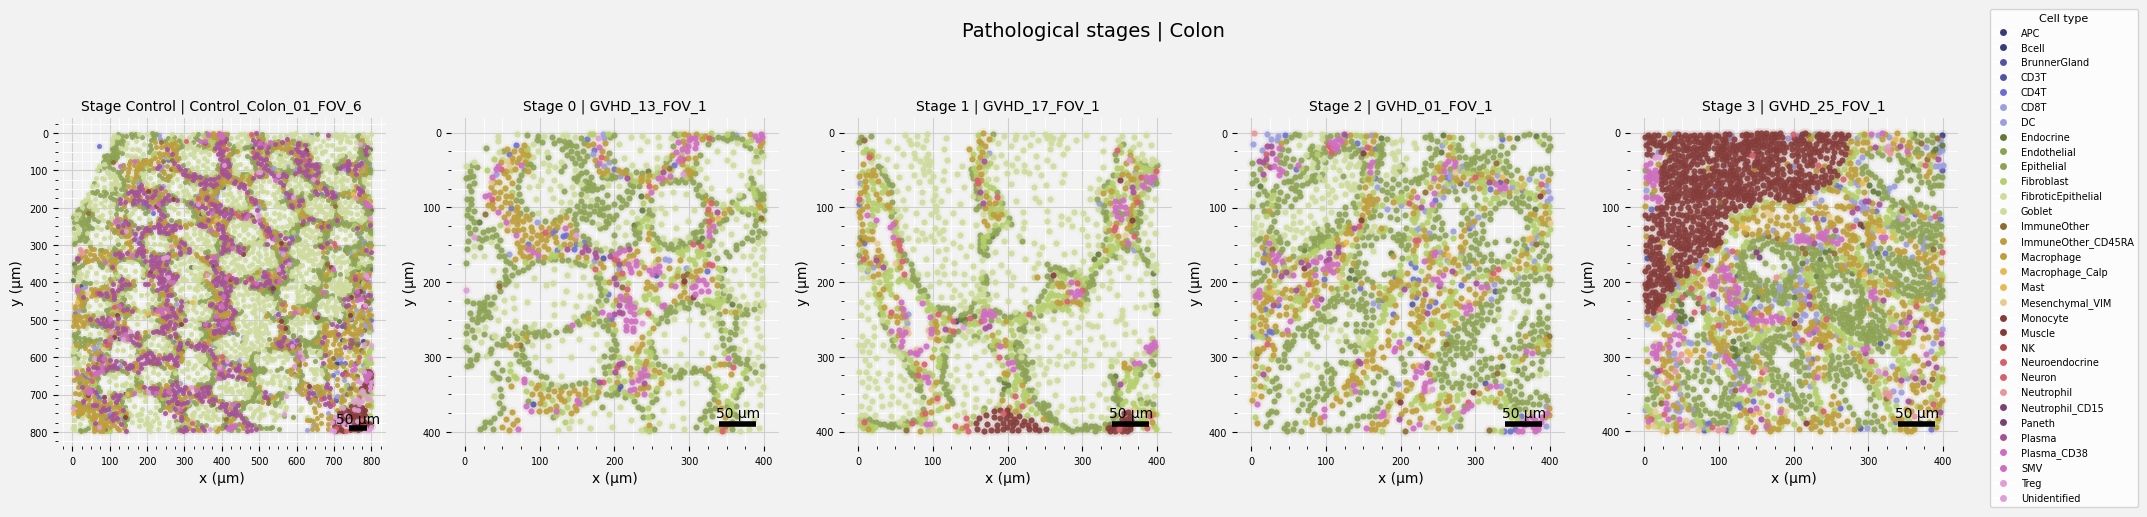

In [15]:
# Pathological stage panels: one row per organ, 5 stages side-by-side.
stage_order = ["Control", "0", "1", "2", "3"]
organ_order = ["Duodenum", "Colon"]

path_panel = (
    merged[~merged["FOV"].astype(str).str.startswith("S_")]
    .assign(_prefer_800=lambda d: (d["Size [um]"] == 800).astype(int))
    .sort_values(["Pathological stage label", "Organ", "_prefer_800", "FOV"], ascending=[True, True, False, True])
    .groupby(["Pathological stage label", "Organ"], as_index=False)
    .first()
)

for organ in organ_order:
    fig, axes = plt.subplots(1, len(stage_order), figsize=(22, 4.4), facecolor="#f2f2f2")
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cell_color_map[ct], markeredgecolor="none", markersize=5, label=ct)
        for ct in all_types
    ]
    for i, stage in enumerate(stage_order):
        ax = axes[i]
        one = path_panel[(path_panel["Organ"] == organ) & (path_panel["Pathological stage label"] == stage)]
        if one.empty:
            ax.text(0.5, 0.5, f"No FOV\n{stage}", ha="center", va="center")
            ax.set_axis_off()
            continue
        row = one.iloc[0]
        title = f"Stage {stage} | {row['FOV']}"
        plot_full_fov_on_ax(ax, row["FOV"], title, show_legend=False)
    fig.suptitle(f"Pathological stages | {organ}", fontsize=14, y=1.04)
    fig.legend(handles=handles, title="Cell type", loc="center left", bbox_to_anchor=(0.905, 0.5), fontsize=7, title_fontsize=8, frameon=True)
    plt.tight_layout(rect=[0, 0, 0.9, 0.93])
    plt.show()

# S_ examples are shown in the dedicated 3-example cell below.

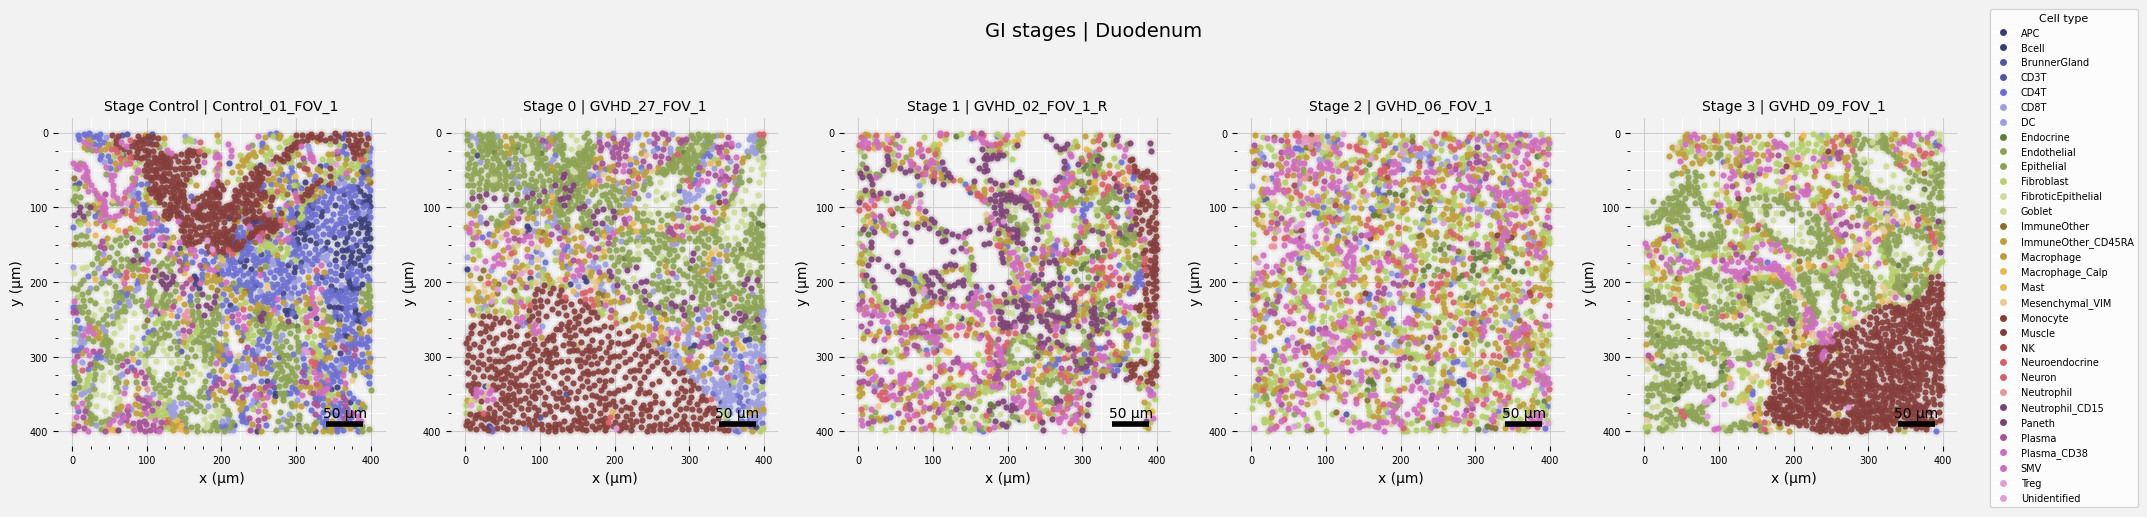

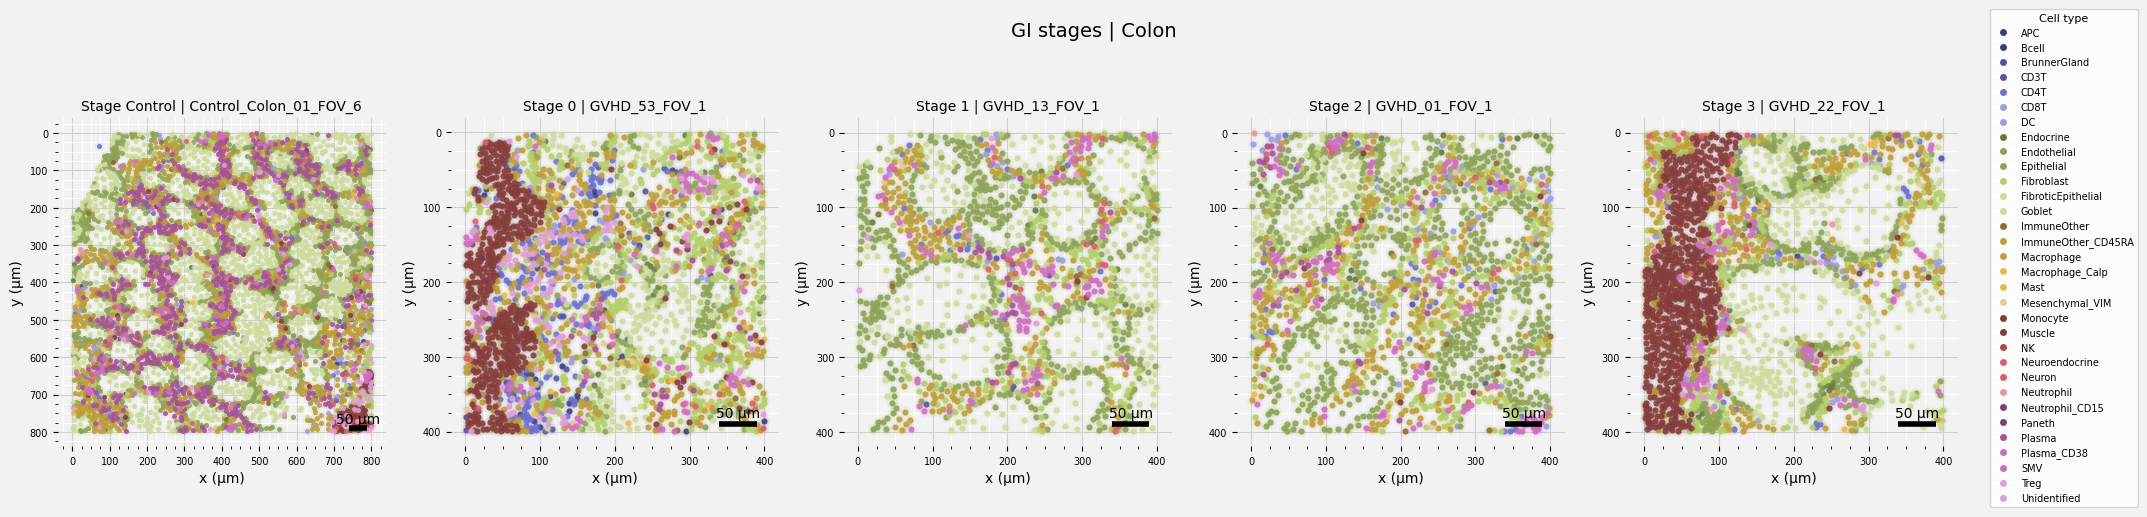

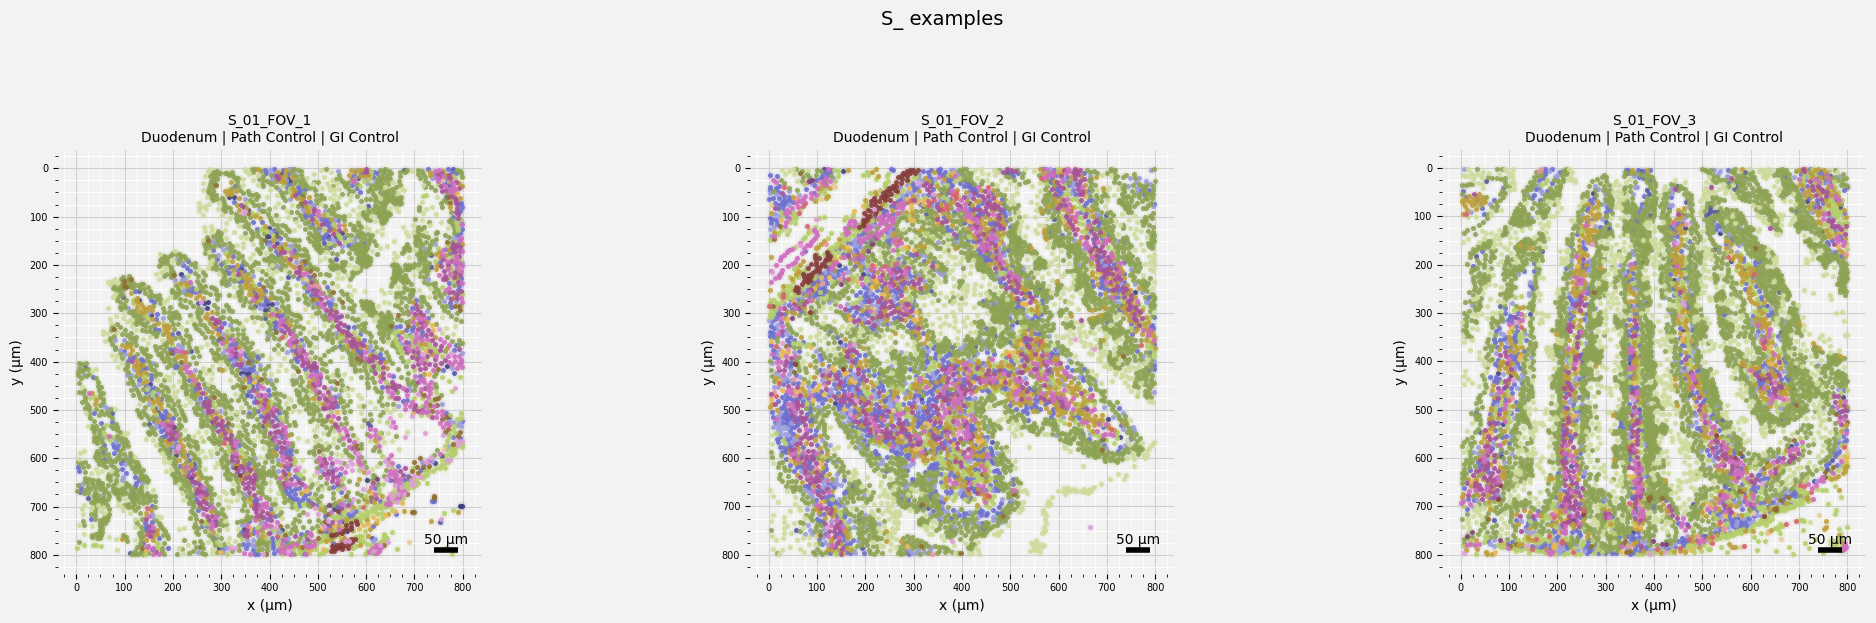

In [16]:
# GI stage panels: one row per organ, 5 stages side-by-side.
gi_panel = (
    merged[~merged["FOV"].astype(str).str.startswith("S_")]
    .assign(_prefer_800=lambda d: (d["Size [um]"] == 800).astype(int))
    .sort_values(["GI stage label", "Organ", "_prefer_800", "FOV"], ascending=[True, True, False, True])
    .groupby(["GI stage label", "Organ"], as_index=False)
    .first()
)

for organ in organ_order:
    fig, axes = plt.subplots(1, len(stage_order), figsize=(22, 4.4), facecolor="#f2f2f2")
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cell_color_map[ct], markeredgecolor="none", markersize=5, label=ct)
        for ct in all_types
    ]
    for i, stage in enumerate(stage_order):
        ax = axes[i]
        one = gi_panel[(gi_panel["Organ"] == organ) & (gi_panel["GI stage label"] == stage)]
        if one.empty:
            ax.text(0.5, 0.5, f"No FOV\n{stage}", ha="center", va="center")
            ax.set_axis_off()
            continue
        row = one.iloc[0]
        title = f"Stage {stage} | {row['FOV']}"
        plot_full_fov_on_ax(ax, row["FOV"], title, show_legend=False)
    fig.suptitle(f"GI stages | {organ}", fontsize=14, y=1.04)
    fig.legend(handles=handles, title="Cell type", loc="center left", bbox_to_anchor=(0.905, 0.5), fontsize=7, title_fontsize=8, frameon=True)
    plt.tight_layout(rect=[0, 0, 0.9, 0.93])
    plt.show()

# 3 standalone S_ examples in one horizontal row.
s_examples = (
    merged[merged["FOV"].astype(str).str.startswith("S_")]
    .sort_values("FOV")
    .drop_duplicates(subset=["FOV"])
    .head(3)
    .reset_index(drop=True)
)

if s_examples.empty:
    print("No S_ examples found")
else:
    n = len(s_examples)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), facecolor="#f2f2f2")
    if n == 1:
        axes = [axes]
    for i, row in s_examples.iterrows():
        title = f"{row['FOV']}\n{row['Organ']} | Path {row['Pathological stage label']} | GI {row['GI stage label']}"
        plot_full_fov_on_ax(axes[i], row["FOV"], title, show_legend=False)
    fig.suptitle("S_ examples", fontsize=14, y=1.03)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()